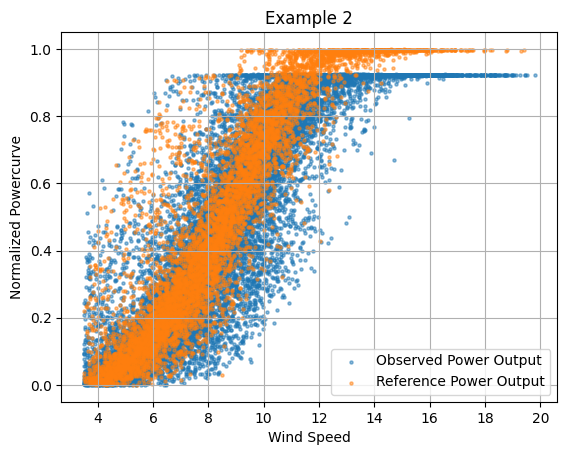

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from wind import get_powercurve, fit_power_curve, fit_weibull, get_loss

df = pd.read_csv("data/Turbine Upgrade Dataset(Pitch Angle Pair, Table7.3).csv")
mask = df['upgrade.status'] == 1

wind_speed = df[~mask]['V'].to_numpy()
wind_speed_ref = df[mask]['V']

power_output = df[~mask]['y_test(r=0.08, normalized)'].to_numpy()
power_output_ref = df[mask]['y_test(r=0.08, normalized)'].to_numpy()
power_curve_max = max(power_output_ref)
power_output_ref = power_output_ref / power_curve_max
power_output = power_output / power_curve_max
plt.grid()
plt.scatter(wind_speed, power_output, s=5, alpha=0.5, label = "Observed Power Output")
plt.scatter(wind_speed_ref, power_output_ref, s=5, alpha=0.5, label = "Reference Power Output")
plt.xlabel("Wind Speed")
plt.ylabel("Normalized Powercurve")
plt.title("Example 2")
plt.legend()

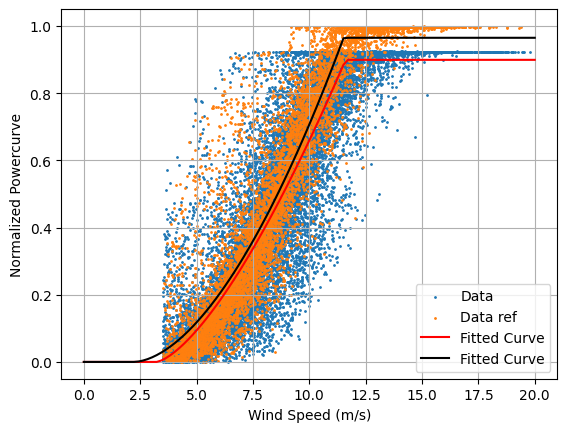

In [32]:
import numpy as np
# Example cubic power curve function

v_fit = np.linspace(0, 20, 100)

P_rated_fit = fit_power_curve(wind_speed, power_output, v_fit)
P_rated_fit_ref = fit_power_curve(wind_speed_ref, power_output_ref, v_fit)

# Plot
plt.scatter(wind_speed, power_output, label='Data', s = 1)
plt.scatter(wind_speed_ref, power_output_ref, label='Data ref', s = 1)

plt.plot(v_fit, P_rated_fit, label='Fitted Curve', color='red')
plt.plot(v_fit, P_rated_fit_ref, label='Fitted Curve', color='black')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Normalized Powercurve')
plt.legend()
plt.grid()
plt.show()


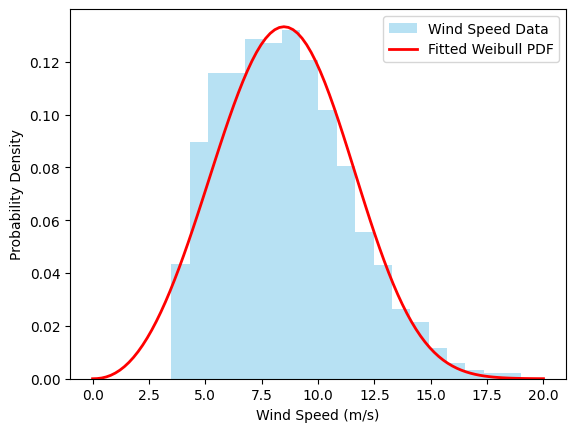

In [33]:

pdf_fitted = fit_weibull(np.hstack([wind_speed,wind_speed_ref]), v_fit)
plt.hist(wind_speed, bins=20, density=True, alpha=0.6, color='skyblue', label='Wind Speed Data')
plt.plot(v_fit, pdf_fitted, 'r-', lw=2, label='Fitted Weibull PDF')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

In [34]:
print(f"Loss = {get_loss(P_rated_fit,P_rated_fit_ref,pdf_fitted,v_fit):.3f}")

Loss = 0.074
